Import des librairies et de la base de données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.ensemble import IsolationForest

df = pd.read_csv(r"C:\Users\utilisateur\Downloads\histo_gazpar_merged.csv")

Préparation des variables : "trend", "hdd_workday", "hdd_weekend".

In [2]:
# Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# Création de la variable 'trend' (tendance temporelle)
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

# Identification des variables de calendrier [cite: 42, 66]
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

# Calcul des interactions HDD x Calendrier [cite: 66, 67]
df['hdd_workday'] = df['hdd'] * (1 - df['is_weekend'])
df['hdd_weekend'] = df['hdd'] * df['is_weekend']

Ajout de la colonne : "Is_Public_Holiday"

In [3]:
def get_french_holidays(years=[2021, 2022, 2023, 2024, 2025]):
    holidays = []
    for year in years:
        # Fêtes fixes
        holidays.extend([
            f"{year}-01-01", f"{year}-05-01", f"{year}-05-08",
            f"{year}-07-14", f"{year}-08-15", f"{year}-11-01",
            f"{year}-11-11", f"{year}-12-25"
        ])
        # Fêtes mobiles (Lundis de Pâques, Ascension, Pentecôte)
        mobiles = {
            2021: ["2021-04-05", "2021-05-13", "2021-05-24"],
            2022: ["2022-04-18", "2022-05-26", "2022-06-06"],
            2023: ["2023-04-10", "2023-05-18", "2023-05-29"],
            2024: ["2024-04-01", "2024-05-09", "2024-05-20"],
            2025: ["2025-04-21", "2025-05-29", "2025-06-09"]
        }
        if year in mobiles:
            holidays.extend(mobiles[year])
    return pd.to_datetime(holidays)

# Application propre sur df_final avant de commencer
df = df.copy()
# On enlève le fuseau horaire (tz_localize(None)) pour pouvoir comparer avec les jours fériés
df['date_parsed_naive'] = pd.to_datetime(df['date_parsed']).dt.tz_localize(None).dt.normalize()
jours_feries = get_french_holidays()
df['Is_Public_Holiday'] = df['date_parsed_naive'].isin(jours_feries).astype(int)

Nettoyage des outliers (méthode Isolation Forest)

In [15]:

# Préparation des données pour l'algo (On utilise la Consommation ET le HDD pour trouver les incohérences)
# (Ex: Conso forte quand il fait chaud = Anomalie)
features = ['valeur_energie_conso', 'hdd']

# Initialisation de l'Isolation Forest : contamination=0.1 signifie qu'on estime qu'il y a environ 10% de données sales
iso_forest = IsolationForest(contamination=0.10, random_state=42, n_jobs=-1)

# Détection (On entraîne sur tout le dataset)
df_clean = df.copy()
df_clean['anomaly'] = iso_forest.fit_predict(df_clean[features].fillna(0))

# Filtrage : l'algo retourne -1 pour les outliers et 1 pour les données normales
df_final = df_clean[df_clean['anomaly'] == 1].drop(columns=['anomaly'])

Application de LMM

In [16]:
# On repart du dataframe
df_lmm = df_final.copy()

# Standardisation
df_lmm['hdd_scaled'] = df_lmm['hdd'] / df_lmm['hdd'].std()
df_lmm['trend_scaled'] = (df_lmm['trend'] - df_lmm['trend'].mean()) / df_lmm['trend'].std()

# Selection du sous échantillon (ici tous les compteurs car ntile100 ==1)
data_for_model = df_lmm[df_lmm['ntile100'] == 1].copy()

# Exécution du modèle
formula = "valeur_energie_conso ~ hdd_scaled + trend_scaled + Is_Public_Holiday"

print("Démarrage du modèle LMM...")
        
# re_formula="~hdd_scaled" : Pente aléatoire pour le HDD (chaque client réagit différemment au froid)
model_lmm = smf.mixedlm(formula, data_for_model, groups=data_for_model["pce"], re_formula="~hdd_scaled")
        
# method=["lbfgs"] est plus robuste pour converger
result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=200)

Démarrage du modèle LMM...


Résultats du LMM

In [17]:
# Résultats du modèle
print(result_lmm.summary())
        
# Effets aléatoires:
print("Exemple d'Effets Aléatoire:")
print(pd.DataFrame(result_lmm.random_effects).T.head(5))

               Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: valeur_energie_conso
No. Observations:  1222945 Method:             REML                
No. Groups:        7081    Scale:              78.1992             
Min. group size:   1       Log-Likelihood:     -4428820.3781       
Max. group size:   250     Converged:          Yes                 
Mean group size:   172.7                                           
-------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept               0.913    0.047   19.322 0.000  0.821  1.006
hdd_scaled             16.512    0.107  153.726 0.000 16.301 16.722
trend_scaled           -1.183    0.009 -126.203 0.000 -1.201 -1.164
Is_Public_Holiday      -0.315    0.043   -7.254 0.000 -0.400 -0.230
Group Var              14.172    0.031                         

Stockage des résultats dans "df_results"

In [40]:
# Extraction des Effets Fixes (Population globale)
beta_hdd_fixed = result_lmm.params['hdd_scaled']

# Extraction des Effets Aléatoires (Spécifiques par client): le dico result_lmm.random_effects contient les écarts pour chaque PCE
re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df = re_df.rename(columns={'hdd_scaled': 'hdd_random_slope', 'Group': 'intercept_random'})
re_df.index.name = 'pce'

# Fusion avec les données d'origine utilisées dans le modèle
df_results = data_for_model.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# Calcul de la pente totale : Pente Client = Pente Moyenne (Fixed) + Écart Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd_scaled'])

Evolution d'une années sur l'autre (pb car ici juste 1 an)

In [36]:
# Agrégation Mensuelle : On fait la moyenne des consos normalisées par mois
summary_lmm = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# Pivot pour comparer les années (2025 vs 2024)
pivot_lmm = summary_lmm.pivot(index='month', columns='year', values='conso_norm')

# Calcul de l'évolution
if 2024 in pivot_lmm.columns and 2025 in pivot_lmm.columns:
    pivot_lmm['Evolution_2025_vs_2024 (%)'] = ((pivot_lmm[2025] - pivot_lmm[2024]) / pivot_lmm[2024]) * 100
    
    print("\n RÉSULTATS FINAUX ")
    print("Évolution de la consommation corrigée du climat (Demand Destruction) :")
    print(pivot_lmm[['Evolution_2025_vs_2024 (%)']].round(2))
    
    avg_drop = pivot_lmm['Evolution_2025_vs_2024 (%)'].mean()
    print(f"\n>> Moyenne globale de la baisse sur la période : {avg_drop:.2f}%")
else:
    print("Pas assez de données communes pour comparer les années.")


 RÉSULTATS FINAUX 
Évolution de la consommation corrigée du climat (Demand Destruction) :
year   Evolution_2025_vs_2024 (%)
month                            
1                             NaN
2                             NaN
3                             NaN
4                             NaN
5                             NaN
7                             NaN
8                             NaN
9                             NaN
10                            NaN
11                            NaN
12                            NaN

>> Moyenne globale de la baisse sur la période : nan%


Réprésentation graphique des résultats
- 1 : Scatter plot pour individus
- 2 : Evolution de la conso sans l'effet météo

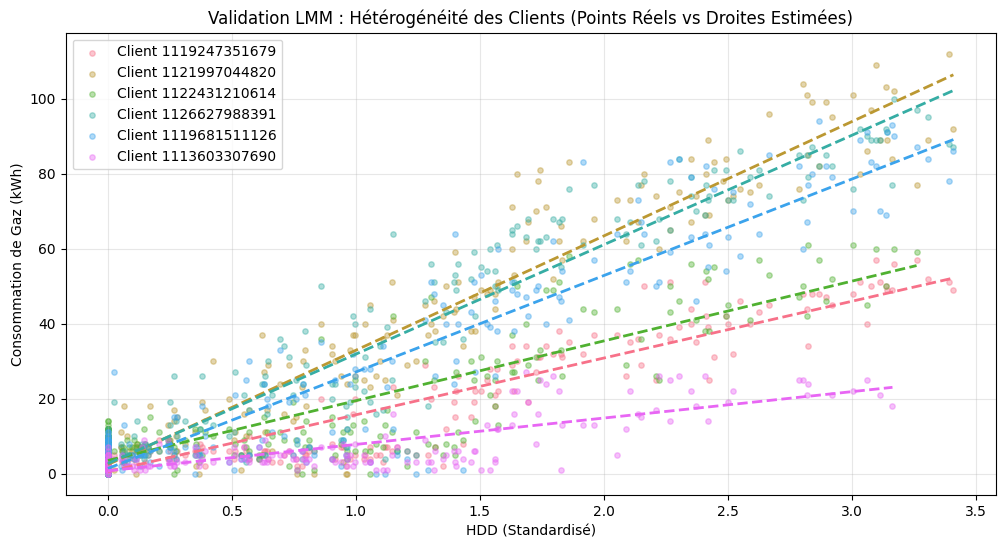

In [ ]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd_scaled'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = result_lmm.params['Intercept']
    intercept_total = intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_total = pce_data['total_hdd_slope'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd_scaled'].min(), pce_data['hdd_scaled'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

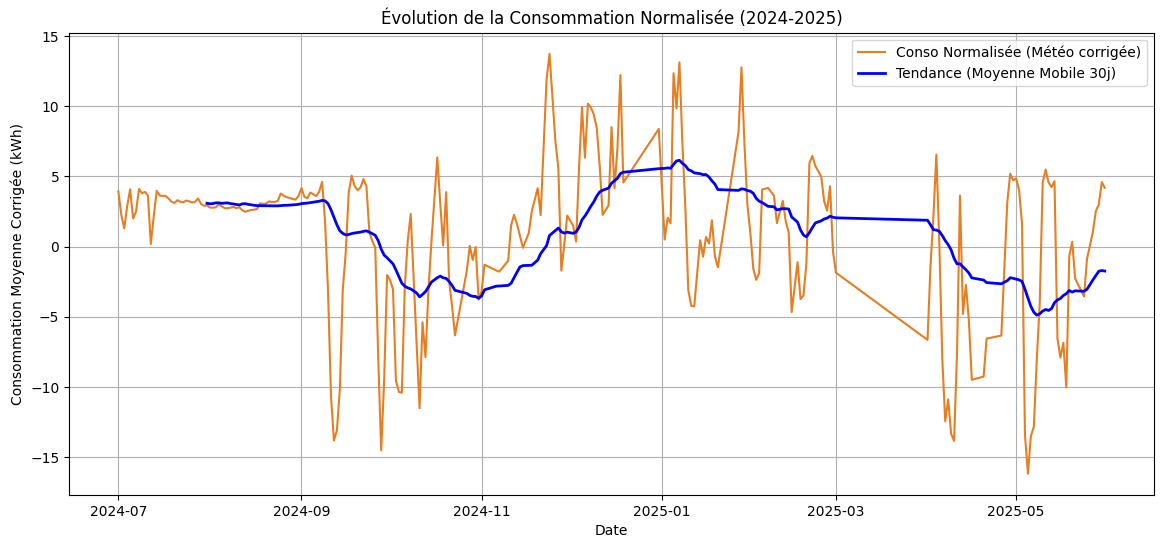

In [ ]:
# Objectif : Voir la courbe de consommation "nettoyée" de la météo
plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()